## Gemaakte opdrachten

***Plaats alle gemaakte P opdrachten hier.***

De P opdrachten staan in de map `notebooks/` en zijn genummerd van 1 t/m 10.

## Onderzoek

***Je onderzoek komt hieronder. Er zijn vast hoofdstukken aangemaakt, maar je mag de volgorde aanpassen en eigen hoofdstukken toevoegen***

In [1]:
from IPython.display import display
from infdsa_mnist import mnist_load, mnist_load_normalized, mnist_output, dataset_exploration, dataset_exploration_output, data_quality, data_quality_output, encoding, encoding_output, decision_tree
from infdsa_mnist.decision_tree import DecisionTreeClassifier

In [2]:
(train_data_raw, test_data_raw) = mnist_load.load_mnist()
x_train_raw, y_train_raw = train_data_raw
x_test_raw, y_test_raw = test_data_raw

(train_data, test_data) = mnist_load_normalized.load_mnist_normalized()
x_train, y_train = train_data
x_test, y_test = test_data

x_train_flat = mnist_load_normalized.flatten_images(x_train)
x_test_flat = mnist_load_normalized.flatten_images(x_test)

### 1 – Data begrijpen

Leg het probleem in eigen woorden uit.

Maak een kort verhaaltje over de database waar we mee gaan werken (MNIST). Je mag dus eerder gemaakte visualisaties ( bijv uit P1) gebruiken.

Vertel om wat voor database het gaat, wat belangerijke eigenschappen zijn etcetera. 

Vat je eerdere bevindingen samen en trek conclusies over de database.

Beantwoord uitgebreid de volgende vragen en bedenk zelf nog meer:

- Welke cijfers zijn moeilijk?

- Welke pixel-kenmerken vallen op?

- Welke variatie zit er in de data?

- Welke informatie is belangrijk voor herkenning?

- Welke designkeuzes heb je gedaan na dit onderzoek (noem op zijn minst 3 concrete gevallen)?

#### Introductie tot MNIST

MNIST is een dataset van handgeschreven cijfers. Het bestaat uit handgeschreven cijfers van 0 t/m 9, waarbij elk cijfer is geschreven door verschillende mensen.

In [3]:
threshold = 1.5

shape, dtype, train_count, test_count, total_count, distribution, balance = dataset_exploration.explore_dataset(x_train_raw, y_train_raw, x_test_raw, y_test_raw, threshold)
distribution = dataset_exploration.digit_distribution(y_train, y_test)

dataset_summary_df = dataset_exploration_output.create_dataset_summary_df(shape, dtype, train_count, test_count, total_count, balance, threshold)
display(dataset_summary_df)
distribution_df = dataset_exploration_output.create_digit_distribution(distribution)
display(distribution_df)

Attribute,Value
Shape of a Single Image,28x28 px
Datatype of a Single Image,8-bit unsigned integer
Number of Training Images,60000
Number of Testing Images,10000
Total Number of Images,70000
Balance Threshold,1.50
Balanced Status,The dataset is balanced.


Digit,Count,Percentage
0,6903,9.86%
1,7877,11.25%
2,6990,9.99%
3,7141,10.20%
4,6824,9.75%
5,6313,9.02%
6,6876,9.82%
7,7293,10.42%
8,6825,9.75%
9,6958,9.94%


De tabellen hierboven tonen het volgende aan:
- De hoeveelheid afbeeldingen voor zowel de training als test set
- De vorm en datatypes voor elke afbeelding
- De balans van de dataset (of er evenveel afbeeldingen zijn voor elk cijfer)

#### Welke cijfers zijn moeilijk?

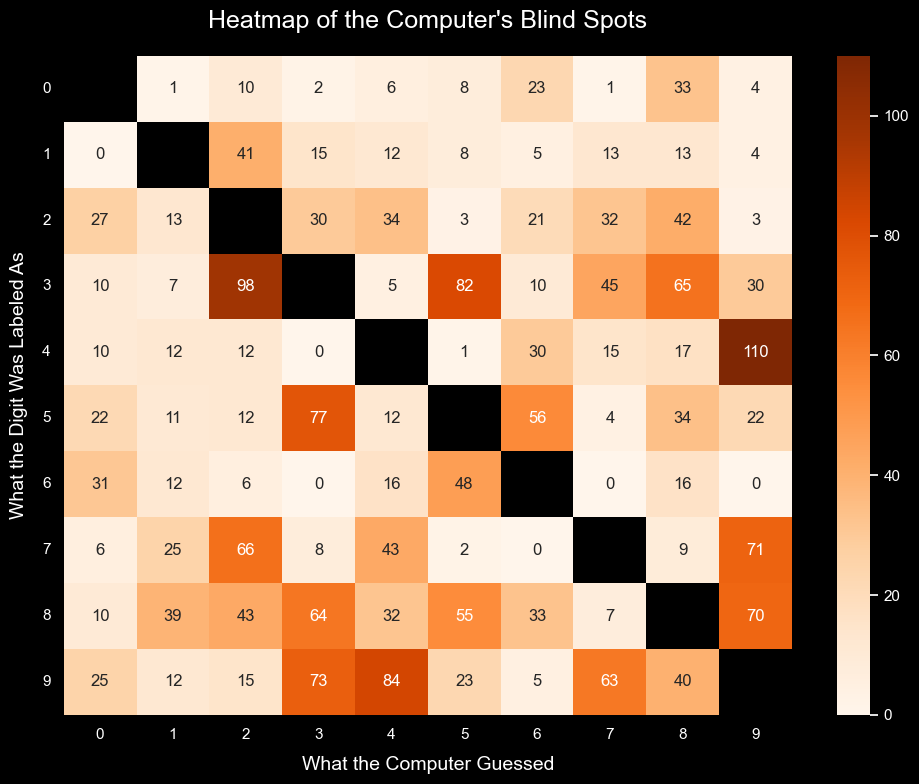

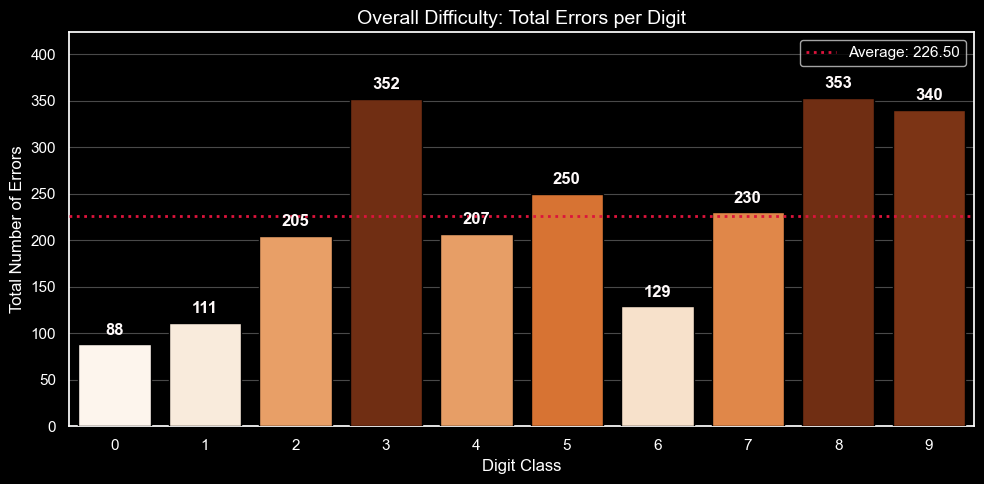

In [4]:
error_matrix = data_quality.get_error_matrix(x_train_raw, y_train_raw)

data_quality_output.display_error_heatmap(error_matrix, title="Heatmap of the Computer's Blind Spots")
mnist_output.display_total_errors_barplot(error_matrix, title="Overall Difficulty: Total Errors per Digit")

De heatmap en barplot hierboven tonen de moeilijkheid van het herkennen van verschillende cijfers. Hieronder volgen de meest opvallende bevindingen gebaseerd op deze visualisaties, per cijfer:

- **3**: Veel fouten, vooral verwarring met 2 en 5. Waarschijnlijk doordat de pixels die een 3 vormen ook vaak voorkomen in 2 en 5. 3 kan ook anders lijken door een slordig handschrift.
- **8**: Veel fouten, verwarring gebeurt met de meeste andere cijfers. Enkel 0 en 7 worden minder vaak verward met 8. Waarschijnlijk omdat 8 veel pixels heeft die ook in andere cijfers voorkomen, en er geen unieke pixels zijn die enkel in 8 voorkomen.
- **9**: Veel fouten, vooral verwarring met 3, 4 en 7. Waarschijnlijk doordat de pixels die een 9 vormen ook vaak voorkomen in 3, 4 en 7. 9 kan ook anders lijken door een slordig handschrift.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "What digit classes are the most challenging for computers to understand and why?"

#### Welke pixel-kenmerken vallen op?

Op basis van de pixel statistieken analyse vallen de volgende kenmerken op:

- **Randpixels zijn altijd donker**: De pixels aan de randen van de afbeeldingen zijn vrijwel altijd zwart (waarde 0). Alle cijfers zijn gecentreerd, waardoor de buitenste rijen en kolommen vrijwel altijd zwart zijn. Dit betekent dat deze pixels weinig tot geen informatie bevatten voor het classificeren van cijfers.
- **Centrale pixels zijn het actiefst**: De pixels rondom het midden van het beeld hebben de hoogste gemiddelde pixelwaarde. Dit komt doordat alle cijfers gecentreerd zijn en dus het meest in het midden voorkomen.
- **Standaarddeviatie onthult structurele grenzen**: De standaarddeviatie per pixel is het hoogst op de plekken waar de structuur van een cijfer varieert. Deze pixels zijn vaak de plekken die bepalen wat voor vorm een cijfer heeft. Zo kan het verschil tussen een '7' met of zonder streep in het midden worden teruggevonden in de standaarddeviatie van de pixels op die plek.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "Pixel Statistics"

- **Elke klasse heeft een eigen "heatmap-profiel"**: Als je de gemiddelde pixelwaarden per cijfer berekent, ontstaat er per cijfer een herkenbaar patroon. Zo heeft het cijfer '1' een smalle verticale hotspot, terwijl '0' een ronde ring laat zien.
- **Cijfers met weinig pixels hebben lage gemiddelde pixelwaarden**: Het cijfer '1' heeft de laagste gemiddelde pixelwaarde (rond 20), terwijl '0' de hoogste heeft (rond 44). Dit komt doordat eenvoudige cijfers als '1' en '7' structureel minder pixels nodig hebben om herkenbaar te blijven.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "What is the average pixel value for each single digit in the dataset?"

#### Welke variatie zit er in de data?

De MNIST dataset bevat meerdere soorten variatie die het classificeren uitdagender maken:

- **Schrijfstijlvariatie**: Hetzelfde cijfer kan er heel anders uitzien afhankelijk van de schrijver. Een '7' kan geschreven worden met of zonder horizontale streep, met een scherpe of ronde hoek bovenaan, recht of schuin.
- **Kanteling en rotatie**: Cijfers kunnen licht gekanteld zijn, waardoor een scheve '9' meer op een '4' kan lijken.
- **Culturele schrijfstijlen**: De dataset is verzameld van verschillende schrijvers, inclusief internationale stijlen. Zo wordt een '1' in sommige landen geschreven met een schuine lijn erboven (waardoor het op een '7' lijkt) Ook heeft een '7' in sommige landen een streep door het midden.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "How can multiple handwritten digits of the same digit class differ visually whilst still being recognizable as that digit?"

- **Dikte van de strepen**: Sommige schrijvers gebruiken dikke, vette lijnen terwijl anderen dunne, fijne lijnen schrijven. Dit beïnvloedt direct hoeveel pixels actief zijn in een afbeelding.
- **Grootte en schaal**: Hoewel alle afbeeldingen 28×28 zijn, kan het cijfer zelf groter of kleiner zijn binnen dat kader. Een klein geschreven '1' in het midden verschilt pixelmatig sterk van een grote '1' die bijna het hele beeld vult.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "Pixel Statistics"

- **Slordigheidsvariatie**: Sommige cijfers zijn slordig geschreven, met open lussen of onduidelijke verbindingen. Een niet-gesloten '0' kan lijken op een '6' of een 'c'-achtige vorm.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "How legible are the handwritten digits in the MNIST dataset?"

#### Welke informatie is belangrijk voor herkenning?

Niet alle pixelinformatie is even waardevol voor het herkennen van een cijfer. Op basis van de analyses kunnen we het volgende concluderen:

- **Structurele vorm**: De globale vorm van het cijfer is de meest bepalende factor. Of een cijfer een lus heeft, een rechte lijn, een curve, of een combinatie daarvan, bepaalt in grote mate welk cijfer het is. Een model moet de structuur kunnen herkennen en niet alleen de exacte pixelposities.
- **Relatieve positie van pixels**: Waar pixels zich bevinden ten opzichte van elkaar zegt meer dan de absolute positie. De verhouding tussen boven- en onderkant, of links en rechts, geeft structurele informatie over het cijfer.
- **Symmetrie**: Sommige cijfers zijn (bijna) symmetrisch, zoals '0' en '8'. Symmetrie kan een nuttig kenmerk zijn om deze cijfers te onderscheiden van asymmetrische cijfers.
- **Randpixels zijn niet erg informatief**: Zoals eerder gezien, zijn de pixels aan de buitenste randen bijna nooit actief. Het weggooien van deze pixels (bijv. door downscaling of cropping) heeft weinig effect op de herkenning maar scheelt opslag en berekening.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "Pixel Statistics"

- **Aanwezigheid van gesloten vormen (lussen)**: Cijfers zoals '0', '6', '8', en '9' bevatten gesloten lussen. Of een lus gesloten is of niet, is cruciale informatie. Zo kan een open lus de herkenning van een cijfer veranderen van een '9' naar een '4'.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "What digit classes are the most challenging for computers to understand and why?"

- **Horizontale en verticale lijnstukken**: Cijfers als '4', '7', en 'T'-achtige vormen worden gekenmerkt door een combinatie van horizontale en verticale lijnen. Het detecteren van deze lijnsegmenten helpt bij onderscheid.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "How can multiple handwritten digits of the same digit class differ visually whilst still being recognizable as that digit?"

#### Welke designkeuzes heb je gedaan na dit onderzoek?

Op basis van de bovenstaande analyses zijn de volgende concrete designkeuzes gemaakt:
- **Normalisatie van pixelwaarden (0–1 in plaats van 0–255)**: Omdat de ruwe pixelwaarden liggen tussen 0 en 255, en modellen beter werken met kleine getallen, worden alle pixelwaarden gedeeld door 255. Dit maakt het leerproces stabieler en sneller, zonder dat er informatie verloren gaat.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "How large is a single image in terms of shape and datatype?"

- **Binarisatie als alternatieve encoding**: Omdat de achtergrond consistent zwart is en de cijfers wit/grijs, is het mogelijk om pixelwaarden te binariseren (alles boven een drempel wordt 1, de rest 0). Dit reduceert de informatie tot alleen de aanwezigheid of afwezigheid van een pixel, wat efficiënter is in geheugen.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "Pixel Statistics"

- **Gebruik van features in plaats van ruwe pixels**: In plaats van alle 784 pixels direct door te sturen naar een model, worden er features berekend (zoals gemiddelde pixelwaarde per kwadrant, het aantal actieve pixels, etc.). Dit vermindert de dimensionaliteit aanzienlijk en zorgt ervoor dat het model sneller en efficiënter kan werken.
- **Extra aandacht voor moeilijke cijfers (3, 8, 9)**: Omdat uit de foutmatrix bleek dat '3', '8', en '9' het vaakst worden verward, zijn de gekozen features zo ontworpen dat ze juist deze cijfers beter kunnen onderscheiden.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "What digit classes are the most challenging for computers to understand and why?"

- **Downscaling overwegen**: Omdat de buitenste rijen en kolommen van de 28×28 afbeelding bijna nooit actief zijn, kan de afbeelding worden ingekromd of verkleind (bijv. naar 20×20) zonder veel informatie te verliezen. Dit scheelt opslag en rekentijd.

> Bron: `notebooks/01_dataset_exploration.ipynb`, sectie "Which pixels are generally "light" (high pixel value) and which pixels are generally "dark" (low pixel value) across the dataset?"

### 2 Encoding

Ontwerp hoe je systeem input zal verwerkten.

- Welke preprocessing stappen ga je toepassen? Den aan bijv grayscale maken / binarisation/ downscaling etc.

Bijvoorbeeld:
- binarization
- downscaling

- hoeveel bytes per afbeelding krijg je dan?
- welke encoding gebruik je?

Maak een tabel waarin je verschillende encodings met elkaar vegelijkt op efficientie.

#### Welke preprocessing stappen ga je toepassen?
- **Normalisatie**: Alle pixelwaarden worden gedeeld door 255, waardoor ze tussen 0 en 1 liggen. Hierdoor weet het model dat er geen pixelwaarden boven 1 zijn, wat het leerproces stabieler maakt.
- **Grijswaarden**: Omdat de afbeeldingen in RGB worden aangeleverd, maar de kleurinformatie niet relevant is voor het herkennen van cijfers, worden de afbeeldingen omgezet naar grijswaarden. Dit vermindert de hoeveelheid data per pixel van 3 (R, G, B) naar 1 (grijswaarde). Dit scheelt opslagruimte en rekentijd zonder een verlies van belangrijke informatie.

Ik heb gekeken naar binning, gezien dit als beste optie uit de benchmarking kwam, maar uiteindelijk ervoor gekozen deze niet toe te passen. Hoewel binning een aanzienlijke geheugenreductie oplevert, zou dit bij de implementatie de complexiteit toch omhoog halen doordat er bit-packing nodig is om de 2-bits representatie van elke pixel op te slaan. Gezien de beperkte tijd en de relatief goede prestaties zonder binning, heb ik ervoor gekozen om deze stap over te slaan en me vooral te richten op het ontwerpen van een efficiënt en simpel model.

##### Hoeveel bytes per afbeelding krijg je dan?
- **Pre-preprocessing (RGB, 0-255 [uint8])**: 784 pixels x 3 kanalen x 8 bits per kanaal = 2352 bytes per afbeelding.
- **Na Normalisatie**: 784 pixels x 3 kanalen x 32 bits (float32) = 9408 bytes per afbeelding.
- **Na Grijswaarden**: 784 pixels x 1 kanaal x 32 bits = 3136 bytes per afbeelding.

Hoewel normalisatie de hoeveelheid data per pixel vergroot (van 8 bits naar 32 bits), is dit nodig voor een stabiel leerproces.

#### Efficiëntie van verschillende encodings op basis van geheugenverbruik en accuraatheid
> De resultaten zijn gebaseerd op benchmarks uitgevoerd met een Decision Tree Classifier getraind op de volledige trainingsset en geëvalueerd op de testset.

In [5]:
full_subset = decision_tree.create_subset(x_train_raw, y_train_raw, subset_size=len(x_train_raw))

clf = DecisionTreeClassifier.fit_best_depth(
    full_subset["features"],
    full_subset["labels"],
    x_test_raw,
    y_test_raw,
    depth_range=range(1, 16)
)

Depth  1: 20.28%
Depth  2: 33.51%
Depth  3: 36.72%
Depth  4: 40.33%
Depth  5: 42.22%
Depth  6: 46.08%
Depth  7: 49.45%
Depth  8: 52.50%
Depth  9: 54.62%
Depth 10: 55.52%
Depth 11: 56.81%
Depth 12: 56.52%
Depth 13: 54.87%
Depth 14: 52.15%
Depth 15: 48.31%

Best depth: 11 (56.81% accuracy)


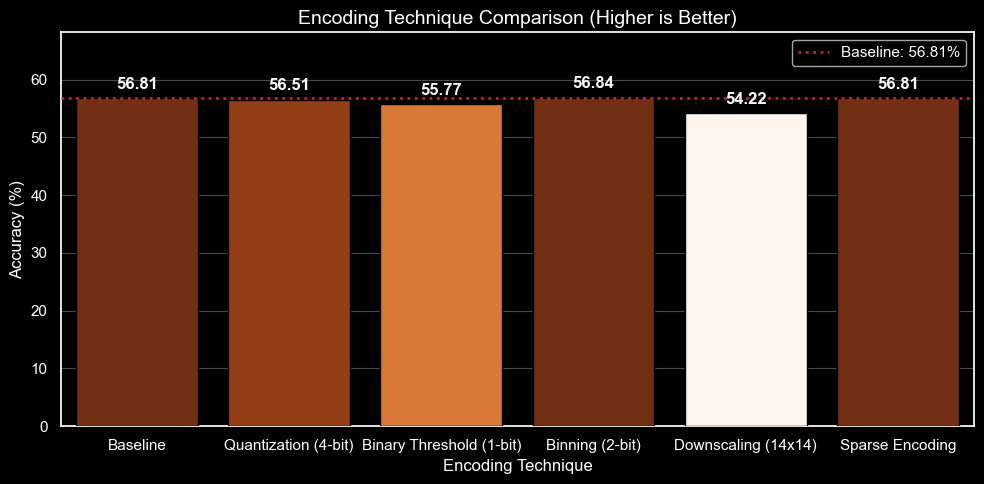

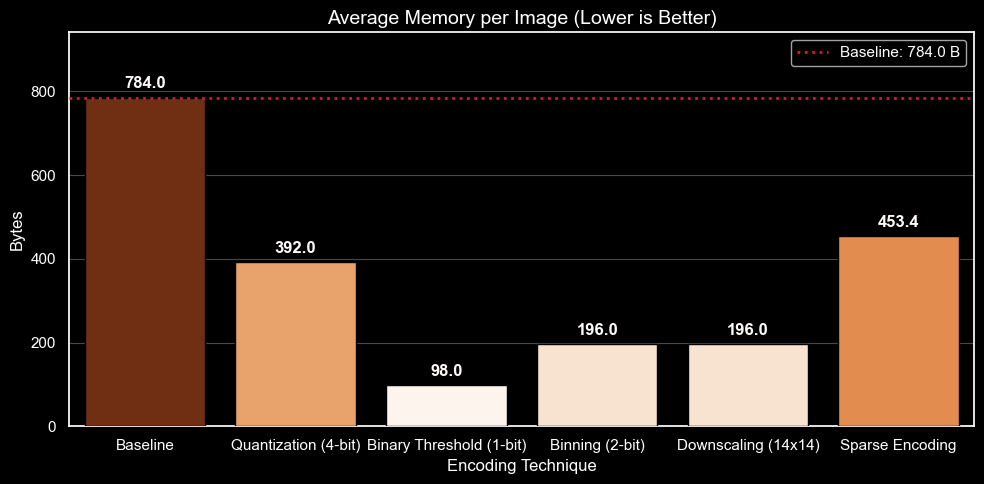

In [6]:
results = encoding.benchmark_encodings(clf, x_test_raw, y_test_raw)
encoding_output.plot_encoding_comparison(results)

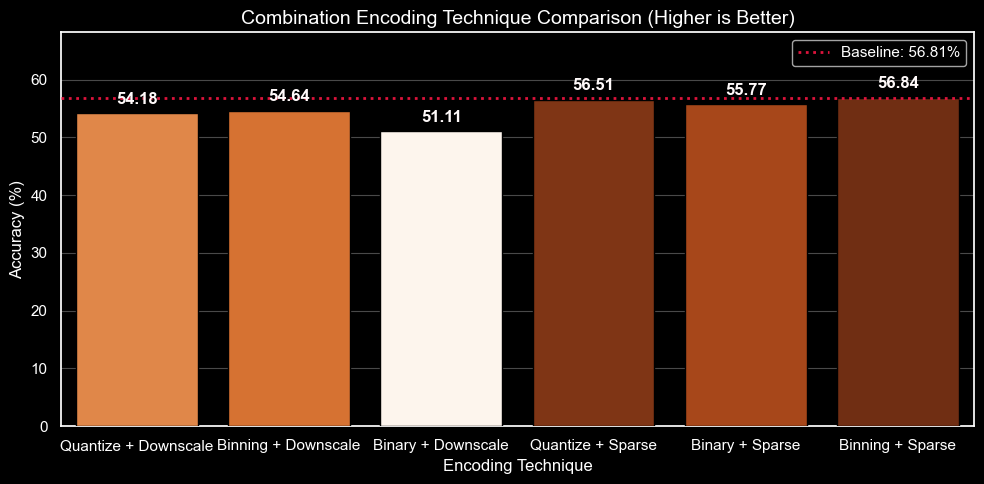

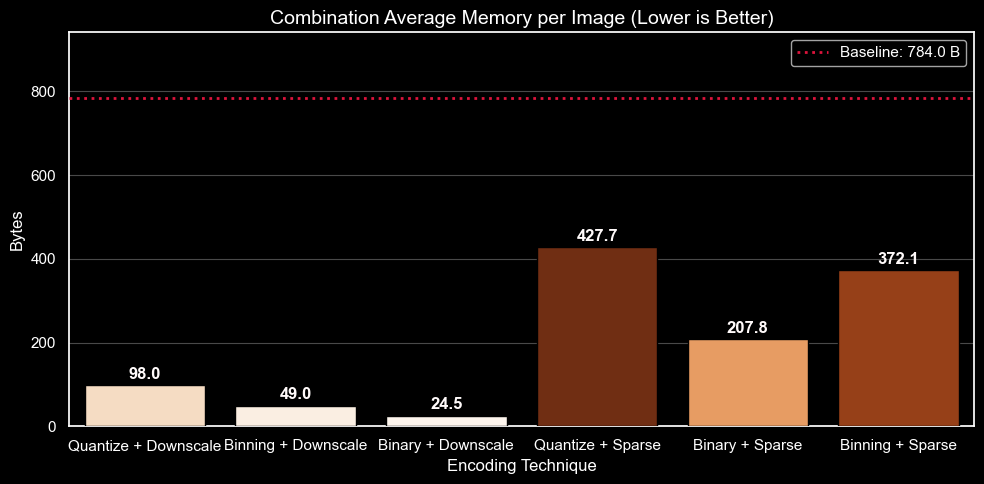

In [7]:
combination_results = encoding.benchmark_combinations(clf, x_test_raw, y_test_raw)
encoding_output.plot_encoding_comparison(
    combination_results,
    title_prefix="Combination",
    baseline_accuracy=results["Baseline"]["accuracy"] * 100,
    baseline_bytes=results["Baseline"]["avg_bytes"]
)

#### Vergelijking van encodingtechnieken

> Bron: `notebooks/04_encoding.ipynb`, secties "Benchmarking Encoding Techniques" en "Analyzing the Results"

#### Gekozen encoding: Binning

Op basis van de benchmarks, kwam binning als beste naar boven. Het groepeert pixelwaarden in 4 niveaus (0-63 -> 0, 64-127 -> 1, 128-191 -> 2, 192-255 -> 3), zodat elke pixel in 2 bits past. Dit levert een geheugenreductie van 75% op: van 784 naar 196 bytes zonder enig verlies in accuraatheid. Daarnaast vereist binning geen reconstructiestap, wat het eenvoudig maakt om te implementeren op een apparaat met beperkte resources.

Alternatieven presteren minder goed in deze afweging:
- Binary thresholding biedt de grootste reductie (87,5%), maar kost ~1 procentpunt accuraatheid.
- Downscaling reduceert even sterk als binning, maar verliest 2,59% accuraatheid.
- Sparse encoding is inconsistent: het verschilt sterk per afbeelding.

> Bron: `notebooks/04_encoding.ipynb`, sectie "Conclusion"

> **Goed om te weten**: Binning zal niet gebruikt worden in een neuraal netwerk, gezien een neuraal netwerk de specifieke pixelwaardes inleest en gebruikt als features. Doordat neurale netwerken gevoeliger zijn voor pixelintensiteit, zou het moeten werken met minder informatie, waardoor het model zwakker zou zijn dan gewild.

### 3 – Feature engineering

Je hebt nu zelf features gemaakt en met verschillende features geexperimenteerd in meerdere P opdrachten. 

Bespreek hier wat goede features zijn.

- Kies minimaal 5 features

- Leg per feature uit:
    - wat meet het?
    - waarom helpt dit?
    - welke features zijn goed/slecht/beter/slechter en waarom?

- Hoe ben je tot je conclusies gekomen? Doe dit aan de hand van je eerder gemaakte werk in de P opdrachten.

In de P opdrachten heb ik meerdere features handmatig ontworpen en getest. Één van de features bestaat uit 4 sub-features (de gemiddelde pixelintensiteit per kwadrant), die ook apart doorgegeven kunnen worden aan het model. Hierom zijn er als het ware zowel 5 als 8 features, afhankelijk van de aangehouden definitie. Hieronder worden de features beschreven, inclusief wat ze meten, waarom ze helpen, en hoe goed of slecht ze zijn in vergelijking met elkaar.

#### Feature 1: Pixel intensiteit (average pixel percentage)

**Wat meet het?**
De mean pixelintensiteit van de afbeelding, oftewel het gemiddelde van alle pixelwaarden (genormaliseerd tussen 0 en 1).

**Waarom helpt dit?**
Cijfers met meer pixels (zoals '8' en '9') hebben een hogere gemiddelde pixelintensiteit dan cijfers met minder pixels (zoals '1' en '7'). Dit geeft een ruwe indicatie van hoe "vol" een cijfer is, wat kan helpen bij het onderscheiden van eenvoudige cijfers van complexere cijfers.

**Goed of slecht?**
Hoewel deze feature een algemeen onderscheid kan maken tussen cijfers met veel of weinig pixels, is het op zichzelf niet erg onderscheidend. Veel cijfers kunnen vergelijkbare gemiddelde pixelwaarden hebben, waardoor deze feature vooral nuttig is als gateway naar meer specifieke features.
> Bron: `notebooks/03_decision_tree.ipynb`, sectie "1. Pixel Intensity"

#### Feature 2: Symmetrie

**Wat meet het?**
De mate waarop het cijfer symmetrisch is, uitgedrukt als een waarde van 0 (totaal asymmetrisch) tot 1 (perfect symmetrisch), gemeten langs zowel de horizontale als verticale as.

**Waarom helpt dit?**
Sommige cijfers zijn structureel symmetrisch, zoals '0' en '8', terwijl andere duidelijk asymmetrisch zijn, zoals '7' en '2'. Deze feature helpt het model onderscheid te maken tussen die twee groepen zonder individuele pixels te vergelijken.

**Goed of slecht?**
Een nuttige feature voor het onderscheiden van symmetrische van asymmetrische cijfers. Minder effectief wanneer twee cijfers allebei asymmetrisch zijn, zoals '2' vs. '6', of wanneer slordig handschrift een normaal symmetrisch cijfer asymmetrisch maakt.

> Bron: `notebooks/03_decision_tree.ipynb`, sectie "2. Symmetry"

#### Feature 3: Centraal punt concentratie

**Wat meet het?**
De gemiddelde pixelintensiteit in het midden van de afbeelding — hoe "gevuld" het centrum van het cijfer is.

**Waarom helpt dit?**
Cijfers verschillen sterk in hoeveel activiteit ze hebben in het midden van het beeld. Zo heeft '0' een lege kern, terwijl '8' en '1' juist veel activiteit in het midden hebben. Dit kenmerk pikt dat verschil op zonder naar de rest van het beeld te kijken.

**Goed of slecht?**
Effectief voor cijfers met een duidelijk lege of gevulde kern. Minder onderscheidend voor cijfers waarbij het centrum toevallig vergelijkbaar gevuld is, of waarbij het cijfer iets verschoven is geschreven waardoor het midden net anders uitpakt.

> Bron: `notebooks/03_decision_tree.ipynb`, sectie "3. Center Point"

#### Feature 4: Aspect ratio

**Wat meet het?**
De verhouding van breedte tot hoogte van het cijfer.

**Waarom helpt dit?**
De globale vorm van een cijfer verschilt per klasse. Een '1' heeft typisch een smalle verhouding, terwijl een '0' of '8' meer vierkant is. Dit kenmerk vat de globale vorminformatie samen in één getal.

**Goed of slecht?**
Nuttig als aanvullend kenmerk, maar gevoelig voor schrijfstijlvariatie. Zo kan een brede '1' of een smalle '0' kan de waarde vervormen, waardoor het minder betrouwbaar is als enige onderscheidend kenmerk. Ook kan kanteling van een cijfer de verhouding beïnvloeden zonder dat het cijfer zelf van vorm verandert. Werkt het best in combinatie met andere features.

> Bron: `notebooks/03_decision_tree.ipynb`, sectie "4. Aspect Ratio"

#### Feature 5: Pixelintensiteit per kwadrant

**Wat meet het?**
De gemiddelde pixelintensiteit in elk van de vier kwadranten van het beeld: linksboven, rechtsboven, linksonder en rechtsonder. Dit levert vier afzonderlijke waarden op die elk apart aan het model worden doorgegeven.

**Waarom helpt dit?**
De verdeling van pixels over de vier kwadranten verschilt sterk per cijfer. Zo heeft '7' typisch veel activiteit rechtsboven en weinig linksonder, terwijl '4' juist activiteit heeft in meerdere kwadranten. Door de kwadranten los door te geven, kan de beslisboom er per node selectief gebruik van maken.

**Goed of slecht?**
De sterkste feature in de set: het geeft vier onafhankelijke ruimtelijke signalen die samen de grove structuur van het cijfer vastleggen. De keerzijde is dat schrijfstijlvariaties de kwadrantwaarden kunnen verschuiven, waardoor de feature minder stabiel is voor slordig geschreven cijfers.

> Bron: `notebooks/03_decision_tree.ipynb`, sectie "5. Pixel Intensity per Region"

#### Vergelijking: handmatige features vs. ruwe pixels

Bij het testen met Gini impurity als splitsingscriterium bleek het volgende:

- **Ruwe pixels (784 features)**: 88,09% accuraatheid
- **Handmatige features (8 features)**: 59,68% accuraatheid
- **Combinatie van beide**: 88,45% accuraatheid

De handmatige features bieden aanzienlijk minder informatie dan de 784 ruwe pixelwaarden. De Gini impurity helpt wel (59,68% vs. 56,81% met de eigen threshold methode), maar compenseert het informatieverlies niet volledig. De combinatie van beide geeft een marginale verbetering boven ruwe pixels alleen, wat aantoont dat de handmatige features toch aanvullende informatie bevatten.

> Bron: `notebooks/07_decision_tree_gini.ipynb`, secties "Chapter 3 Features" en "Combined Features"

### 4 Model/ Algoritme keuze

Je hebt nu meerdere modellen/algoritmes gebouwd en laten zien in de P opdrachten.
Vergelijk nu de werking op mnist. 

Kies zelf minimaal nog een algoritme om mee te testen (je geen externe libraries gebruiken behalve keras/numpy of andermans code). Let er op dat als je keras gebruikt voor onderzoek je deze niet in je eindproduct mag gebruiken, dus je zou het zelf moeten implementeren. 

Voor elke aanpak maak een vergelijking:

- hoe werkt het?

- wat gebruikt het aan data?

- Welke gaf welke resultaten?

- hoeveel geheugen kostte het?

In hoeverre is je uitleindelijke algoritme algemeen? Test of het alleen werkt het alleen voor de images uit de testset of ook eigengemaakte / verkeerde formaat images. Denk hier over na en probeer je algoritme zo veel mogelijk "niet standaard" gevallen af te vangen.

In de P opdrachten zijn meerdere algoritmes geïmplementeerd en vergeleken. Hieronder wordt elk algoritme beschreven op vier punten: hoe het werkt, welke data het gebruikt, welke resultaten het gaf, en hoeveel geheugen het kostte.

#### Algoritme 1: Decision Tree (eigen implementatie)

**Hoe werkt het?**
Een beslisboom stelt op elk knooppunt een vraag over één feature ("is de pixelintensiteit groter dan drempel X?") en splitst de data op in twee groepen. Dit herhaalt zich recursief totdat een maximale diepte is bereikt of alle voorbeelden in een groep dezelfde klasse hebben. Een nieuw beeld wordt geclassificeerd door de boom van boven naar beneden te doorlopen en bij elk knooppunt de juiste tak te kiezen.

**Welke data gebruikt het?**
De 8 handmatig ontworpen features (zie sectie 3). Voor het trainen op het apparaat zelf werd een subset van 300 trainingsbeelden gebruikt. Voor het volledig trainen op een computer de volledige 60.000 trainingsbeelden.

**Resultaten**
- Diepte 3, subset (300 beelden): **50%** accuraatheid
- Diepte 11, volledige trainingsset: **56,81%** accuraatheid

**Geheugen**
- RAM: ~240 KB (diepte 3, inclusief dataset)
- Opslag: ~240 KB (diepte 3)
- Beide binnen de apparaatlimieten van 256 KB RAM en 1 MB opslag.

> Bron: `notebooks/03_decision_tree.ipynb`

#### Algoritme 2: Decision Tree (Gini impurity, sklearn)

**Hoe werkt het?**
Hetzelfde principe als de eigen implementatie, maar gebruikt Gini impurity als splitsingscriterium. Gini impurity zoekt bij elke split de feature én drempel die de twee resulterende groepen het meest "puur" maakt: zo min mogelijk klassen per groep. Dit leidt tot betere splits dan de eigen drempelmethode.

**Welke data gebruikt het?**
Getest met drie configuraties: alleen ruwe pixels (784 features), alleen de 8 handmatige features, en een combinatie van beide (792 features).

**Resultaten**
- Ruwe pixels (784): **88,09%** accuraatheid
- Handmatige features (8): **59,68%** accuraatheid
- Combinatie (792): **88,45%** accuraatheid

**Geheugen**
Niet expliciet gemeten in de notebook, maar de assumptie is dat het model groter is dan de eigen implementatie vanwege het gebruik van meer features. Dit is echter niet bewezen en zou onderzocht moeten worden als dit model in het eindproduct wordt gebruikt.

> Bron: `notebooks/07_decision_tree_gini.ipynb`

#### Algoritme 3: K-Means Clustering (eigen implementatie)

**Hoe werkt het?**
K-Means groepeert trainingsbeelden per cijferklasse in `k` clusters en berekent per cluster een prototype (het gemiddelde beeld van alle beelden in dat cluster). Bij classificatie wordt het nieuwe beeld vergeleken met alle prototypes; de klasse van het dichtstbijzijnde prototype wordt als voorspelling teruggegeven. Meer prototypes per klasse geven meer nuance maar kosten meer geheugen.

**Welke data gebruikt het?**
Ruwe pixels (784 per beeld) voor de ongeoptimaliseerde versie; gebinde pixels (196 bytes per beeld) voor de geheugengeoptimaliseerde versie.

**Resultaten**
- 4 prototypes per klasse, geen optimalisatie: ~**90%** accuraatheid
- 130 prototypes per klasse, met binning: **95,27%** accuraatheid

**Geheugen**
- Zonder binning: 4 prototypes per klasse < 256 KB RAM
- Met binning: 130 prototypes per klasse < 256 KB RAM

> Bron: `notebooks/05_k_means_clustering.ipynb`

#### Algoritme 4: Lineaire regressie (sklearn)

**Hoe werkt het?**
Lineaire regressie leert een gewogen som van de inputfeatures die zo goed mogelijk de juiste klasse-score voorspelt. Voor een meerklassenprobleem zoals MNIST wordt voor elke klasse (0-9) een apart model getraind dat leert hoe "zeker" het is dat een beeld tot die klasse behoort. De klasse met de hoogste score wordt als voorspelling gekozen.

**Welke data gebruikt het?**
Getest met drie configuraties: ruwe pixels (784), handmatige features (8), en een combinatie van beide (792).

**Resultaten**
- Ruwe pixels (784): **86,03%** accuraatheid
- Handmatige features (8): **51,61%** accuraatheid
- Combinatie (792): **87,20%** accuraatheid

**Geheugen**
Niet expliciet gemeten in de notebook. Dit zou onderzocht moeten worden als dit model in het eindproduct wordt gebruikt.

> Bron: `notebooks/06_linear_regression.ipynb`

#### Algoritme 5: Neuraal netwerk (Keras, met quantisatie)

**Hoe werkt het?**
Een neuraal netwerk bestaat uit meerdere lagen van gewichten. De input (784 pixels) wordt laag voor laag getransformeerd via activatiefuncties totdat de outputlaag een score per klasse geeft. Tijdens training worden de gewichten bijgesteld via backpropagation zodat de voorspellingen steeds beter worden. Na training kan de optimizer worden verwijderd en kunnen de gewichten worden gequantiseerd (float32 -> uint8) om het model kleiner te maken.

**Welke data gebruikt het?**
Genormaliseerde ruwe pixels (784 per beeld, waarden 0-1).

**Resultaten**
- Volledig model: **98,2%-98,5%** accuraatheid
- Na quantisatie (float32 -> uint8): **98,2%-98,5%** accuraatheid (verlies zal binnen margin of error liggen)

**Geheugen**
- Met optimizer: 2,55 MB (te groot voor apparaat)
- Zonder optimizer: 891,65 KB (te groot voor RAM)
- Na quantisatie: **224,77 KB** (past in zowel RAM als opslag)

> Bron: `notebooks/08_simple_neural_network.ipynb`

#### Algoritme 6: Neuraal netwerk (eigen implementatie, geen libraries)

**Hoe werkt het?**
Hetzelfde principe als het Keras-netwerk, maar volledig in NumPy geïmplementeerd zonder externe ML-libraries. Training verloopt in batches (mini-batch gradient descent) zodat de gradiënten informatief genoeg zijn voor zinvolle gewichtsupdates. De implementatie bevat ook Dropout en Batch Normalization (via een externe NumPy-implementatie) om overfitting te verminderen en de generalisatie te verbeteren.

**Welke data gebruikt het?**
Genormaliseerde ruwe pixels (784 per beeld, waarden 0–1).

**Resultaten**
- Zonder batches: ~**10%** accuraatheid (model voorspelt altijd dezelfde klasse)
- Met batches: **97%+** op de testset, **99%+** op de trainingsset
- Met Dropout en Batch Normalization: **98%+** op zowel training als testset

**Geheugen**
Niet expliciet gemeten. Aangenomen wordt dat de modelgrootte vergelijkbaar is met het Keras-model zonder optimizer (~891,65 KB), wat te groot is om volledig in RAM te laden. Verdere optimalisatie zoals quantisatie zou nodig zijn om het binnen de 256 KB RAM-limiet te krijgen.

> Bron: `notebooks/10_nn_nolib.ipynb`

#### Algoritme 7: Support Vector Machine (sklearn)

**Hoe werkt het?** 
Een Support Vector Machine (SVM) zoekt naar de optimale grens tussen verschillende klassen. Dit doet het door de afstand tussen de beslisgrens en de dichtstbijzijnde cijfers uit de trainingsset zo groot mogelijk te maken. Het model trekt als het ware strakke, rechte lijnen in de data om de verschillende cijfers zo breed mogelijk van elkaar te scheiden. Hierdoor kunnen grensgevallen opgevangen worden waar mogelijk.

**Welke data gebruikt het?**
Genormaliseerde ruwe pixels (784 per beeld, waarden 0-1) in een 1D array.

**Resultaten**
- **91,84%** accuraatheid

**Geheugen**
- Opslag: 61,90 KB
- RAM: 61,90 KB

In [8]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pickle

svm_model = LinearSVC(dual=False, C=1.0, random_state=42, max_iter=1000)
svm_model.fit(x_train_flat, y_train)

y_pred = svm_model.predict(x_test_flat)
acc = accuracy_score(y_test, y_pred)
print(f"SVM Accuracy: {acc:.2%}")
model_bytes = pickle.dumps(svm_model)
print(f"Modelgrootte: {len(model_bytes) / 1024:.2f} KB")

SVM Accuracy: 91.84%
Modelgrootte: 61.90 KB


#### Overzicht

| Algoritme                              | Features        | Accuraatheid | Geheugen             |
|----------------------------------------|-----------------|--------------|----------------------|
| Decision Tree (eigen, diepte 3)        | 8 handmatig     | 50%          | ~240 KB              |
| Decision Tree (eigen, diepte 11)       | 8 handmatig     | 56,81%       | 134,70 KB            |
| Decision Tree (Gini)                   | 784 pixels      | 88,45%       | 962,87 KB            |
| Lineaire regressie                     | 784 pixels      | 86,03%       | 124,18 KB            |
| K-Means + binning                      | 196 bytes/beeld | 95,27%       | <256 KB              |
| Neuraal netwerk (Keras, gequantiseerd) | 784 pixels      | 98,2–98,5%   | 224,77 KB            |
| Neuraal netwerk (eigen, NumPy)         | 784 pixels      | 98%+         | ~891 KB (schatting)  |
| Support Vector Machine                 | 784 pixels      | 91,84%       | 61,90 KB             |

### 5 Eindkeuze en Motivatie

Maak nu vergelijkingen tussen verschillende aanpakken, minimaal: 

- accuracy vergelijken tussen methodes

- effect van verschillende datastructuren gebruiken voor verschillende onderdelen in je pipeline

- effect van features

- effect van encoding

- effect van bepaalde settings, zoals k (bij k-means) of diepte (tree)

Dit is je belangrijkste hoofdstuk. Hier verwachten we je gekozen algoritme dat we direct op de MysteryDevice zouden kunnen uitvoeren
- Het moet dus passen in het geheugen

- Het moet passen in RAM als het wordt uitgevoerd

- Het moet goede resultaten geven

Beargumenteer, naar aanleiding van voorgaande hoofdstukken waarom je hiervoor uiteindelijk hebt gekozen.

Zet je werkende pipeline als code in dit hoofdstuk.

Combineer alles tot een pipeline:

**Input -> Encoding -> Feature extraction -> Model -> Output**

Dit is een van de belangrijkste hoofdstukken. Onderbouw je keuzes, leg uit, vergelijk verschillende aanpakken. Maak duidelijk waarom dit de beste oplossing is.

Aan de hand van je keuzes hier moet het eindproduct geprogrammeerd worden (in ***mysterydevice.ipynb*** bestand)

#### Vergelijkingen

De volgende vergelijkingen bouwen stap voor stap op naar de eindkeuze. Per dimensie (accuracy, datastructuren, features, encoding en instellingen) wordt een deelconclusie getrokken die meeweegt in de uiteindelijke afweging.

##### Accuracy tussen methodes

Zie de overzichtstabel in sectie 4. Ruwe pixelwaarden als input leveren altijd hogere accuracy op dan handmatige features, ongeacht het algoritme. Het neurale netwerk (Keras, gequantiseerd) scoort het hoogst met 98,2–98,5%, gevolgd door de eigen NumPy-implementatie (98%+). K-Means met binning scoort 95,27%, de Support Vector Machine scoort 91,84%, de Decision Tree met Gini impurity 88,45% en lineaire regressie 86,03%.

In grote lijnen: **Neuraal Netwerk > K-Means > SVM > Decision Tree > Lineaire Regressie**.

> Bronnen:
>
> `notebooks/03_decision_tree.ipynb`
>
> `notebooks/05_k_means_clustering.ipynb`
>
> `notebooks/06_linear_regression.ipynb`
>
> `notebooks/07_decision_tree_gini.ipynb`
>
> `notebooks/08_simple_neural_network.ipynb`
>
> `notebooks/10_nn_nolib.ipynb`

**Deelconclusie**: Puur op accuracy is het neurale netwerk de sterkste kandidaat. K-Means is ook een sterk alternatief, maar haalt een iets lagere accuracy. Decision trees en lineaire regressie presteren duidelijk minder goed.

##### Effect van datastructuren

In P2 zijn Lists, Queues en Dictionaries vergeleken op taken zoals zoeken, toevoegen en doorlopen van de MNIST dataset.

- **Zoek op label**: Een dictionary organiseert images per key, waardoor het vinden van alle beelden van een bepaald cijfer O(1) kost. Een list of queue vereisen O(n) omdat de data ongesorteerd is. Dit maakt de dictionary significant sneller voor label-gebaseerde taken.
- **Doorlopen van de volledige dataset**: Alle drie structuren vereisen O(n) tijd. In de praktijk was de dictionary iets sneller door interne optimalisaties, maar het verschil is niet significant.
- **Toevoegen en verwerken**: Lists en queues zijn eenvoudig uit te breiden. Een queue handhaaft de volgorde automatisch, wat nuttig is bij het sequentieel verwerken van batches tijdens training.
- **Geheugenverbruik**: Lists hebben de laagste overhead. Dictionaries verbruiken meer geheugen door de opgeslagen keys naast de values. Dit is een nadeel op een apparaat met beperkt RAM.

> Bron: `notebooks/02_data_structures.ipynb`, secties "Tasks to complete for each data structure", "Linear vs Non-linear data structures" en "Conclusion"

**Deelconclusie**: Voor het eindproduct, waarbij inferentie op een apparaat met 256 KB RAM draait, zijn arrays (NumPy) de meest geheugenefficiënte keuze voor het opslaan van gewichten en activaties. Dictionaries zijn nuttig bij het laden van het model vanuit een `.npz` bestand, maar worden daarna meteen omgezet naar arrays.

##### Effect van features

De handmatige features (8 stuks) geven bij elk getest algoritme een lagere accuracy dan ruwe pixelwaarden. Dit is consistent zichtbaar bij zowel de decision tree als lineaire regressie:

- Decision tree (eigen, diepte 11): 56,81% met 8 features vs. 88,09% met 784 pixels (Gini)
- Lineaire regressie: 51,61% met 8 features vs. 86,03% met 784 pixels

De handmatige features vangen de globale structuur van een cijfer op, maar missen de details die nodig zijn om vergelijkbare cijfers (bijv. 3 vs. 8, of 4 vs. 9) van elkaar te onderscheiden. Het neurale netwerk maakt helemaal geen gebruik van handmatige features; het leert zelf via backpropagation welke pixelcombinaties informatief zijn.

> Bronnen:
>
> `notebooks/03_decision_tree.ipynb`, sectie "Analyzing the Depth Experiment"
>
> `notebooks/07_decision_tree_gini.ipynb`, secties "Chapter 3 Features" en "Combined Features"
>
> `notebooks/06_linear_regression.ipynb`, sectie "Custom Features"

**Deelconclusie**: Handmatige feature-engineering helpt niet genoeg voor dit probleem. Ruwe pixels geven betere resultaten, en het neurale netwerk maakt dit vanzelf optimaal door zelf te leren welke pixels relevant zijn. Feature-engineering is dus niet de beste aanpak voor dit probleem, wat K-Means en een neuraal netwerk als betere keuzes doet lijken.

##### Effect van encoding

Uit de benchmarks in P4 bleek binning de beste verhouding tussen geheugenreductie en accuracy voor de decision tree:

- **Binning**: 75% geheugenreductie (784 -> 196 bytes), geen verlies in accuracy
- **Binary thresholding**: 87,5% reductie, ~1% accuracy-verlies
- **Downscaling**: vergelijkbare reductie als binning, ~2,59% accuracy-verlies
- **Sparse encoding**: inconsistent, afhankelijk van hoe sparse een afbeelding is

Bij K-Means maakte binning het mogelijk om van 4 naar 130 prototypes per klasse te gaan, waardoor de accuracy steeg van ~90% naar 95,27%.

> Bronnen:
>
> `notebooks/04_encoding.ipynb`, secties "Analyzing the Results" en "Conclusion"
>
> `notebooks/05_k_means_clustering.ipynb`, sectie "Breaking the memory constraint by optimizing the data input"

Binning werkt bij neurale netwerken zelfs tegen. Het model leert namelijk van de subtiele variaties in pixelwaarden. Binning zou die subtiele informatie verwijderen, waardoor de accuracy zou dalen. Voor een neuraal netwerk is normalisatie de beste keuze. Dit is technisch gezien niet "encoding", maar het is de noodzakelijke preprocessing stap die ervoor zorgt dat het netwerk goed kan leren. Ook is er een mogelijkheid om de pixelwaarden terug te schalen naar `uint8` na training, zodat de modelgrootte kleiner wordt zonder dat dit invloed heeft op de accuracy. Dit heb ik niet in de notebooks uitgewerkt, maar is goed om te overwegen om toe te passen als het neurale netwerk als eindproduct wordt gekozen.

**Deelconclusie**: Binning is de optimale encoding voor modellen die met discrete representaties werken (decision tree, K-Means). Voor het neurale netwerk is normalisatie de juiste keuze. De keuze voor het algoritme bepaalt dus ook de juiste encoding.

##### Effect van settings

| Methode         | Setting                     | Effect                                                                                                                                                                                                         | Overweging                                                                                                                     |
|-----------------|-----------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------|
| Decision Tree   | Diepte                      | Optimum op diepte 11 (56,81%); daarna overfitting. Diepte 3 past in RAM maar scoort slechts ~50%.                                                                                                              | De trade-off tussen geheugen en accuracy is te groot om te accepteren als eindproduct.                                         |
| K-Means         | k                           | Accuracy stijgt logaritmisch met k. Na k=10 neemt winst per extra prototype sterk af. Binning verschuift optimum naar k=130, omdat meer prototypes in hetzelfde geheugen passen en foutrate meer dan halveert. | Meer prototypes geven betere accuracy, maar kosten meer geheugen. Binning maakt meer prototypes mogelijk binnen de RAM-limiet. |
| Neuraal netwerk | Architectuur (Dense layers) | Grotere Dense layer (256 vs. 64 neurons) geeft meer capaciteit om complexe patronen te leren, maar vergroot modelgewicht.                                                                                      | Meer neurons kunnen betere accuracy opleveren, maar moeten worden afgewogen tegen het geheugenbudget.                          |
| Neuraal netwerk | Dropout                     | Hogere dropout dwingt robuustere patronen te leren maar verlaagt confidence. Lagere dropout verhoogt confidence maar vergroot risico op overfitting.                                                           | Een balans moet worden gevonden door te experimenteren.                                                                        |

> Bronnen:
>
> `notebooks/04_encoding.ipynb`, sectie "Training the Classifier on the Full Dataset"
>
> `notebooks/05_k_means_clustering.ipynb`, secties "Further experimentation" en "Breaking the memory constraint by optimizing the data input"
>
> `notebooks/10_nn_nolib.ipynb`, secties "Training with batches" en "Improving the model"

**Deelconclusie**: De instellingen bevestigen dat het neurale netwerk het meest te winnen heeft uit fine-tuning: dropout en early stopping verbeteren de generalisatie significant. Bij Decision Trees en K-Means is de regel "meer is beter" duidelijk zichtbaar, maar het geheugen beperkt tot in hoeverre deze limieten kunnen worden opgerekt. Bij neurale netwerken is er meer flexibiliteit in het vinden van een goede architectuur. In sommige gevallen kan een kleinere Dense layer juist beter presteren dan een grotere, afhankelijk van de context.

#### Eindkeuze: eigen neuraal netwerk (12 modellen, uint8 gewichten)

Mijn eigen neurale netwerk die ik voor P10 had gemaakt had een mooi resultaat gehaald dat enorm dicht bij mijn Keras implementatie kwam. Tijdens het maken van dat neurale netwerk maakte ik echter gebruik van Batch Normalization code die ik had gevonden op GitHub. In overleg met de docent werd vastgesteld dat ik deze externe code enkel voor experimentele doeleinden mocht gebruiken in P10 en dat duidelijk moest aangeven. Ook hebben we afgesproken dat deze code niet gebruikt mocht worden in het eindproduct.

De code die ik als basis heb gekozen was uiteindelijk toch het neurale netwerk met de Batch Normalization. Om ervoor te zorgen dat ik tot een eerlijke oplossing kwam, begon ik direct met de Batch Normalization en alle referenties hiervan uit de code te halen voor de eindopdracht. Dit zorgde ervoor dat mijn neurale netwerk sneller begon met overfitten en minder goed kon generaliseren. Gelukkig had het model ook een early stopping algoritme (met patience) en een dropout rate, zodat het niet te snel zou imploderen.

Daarna maakte ik optimalisaties om een groot model in RAM te kunnen laden voor inference. Dit heb ik gedaan door de weights op te slaan als uint8. Deze laat ik tijdens inference per kolom tijdelijk converteren naar float32, zodat het RAM nooit wordt overladen door float32 waarden. Met mijn initiële design die gebruik maakte van 2 hidden layers (256 -> 128), was dit net genoeg om binnen de 256 KB RAM te blijven.

Hierna begon ik met het tacklen van de extra opdracht: dat mijn neuraal netwerk aan kan geven als iets niet een cijfer is. Hiervoor heb ik een aantal test `.png` bestanden gemaakt. Zo heb ik alle cijfers (0-9) gemaakt en een aantal niet-cijfers (A, B, Q, stervorm, smiley). Hier kwam ik erachter dat een neuraal netwerk koste wat kost iets wilt plaatsen in een "bekend" hokje, zelfs al lijkt het niet echt op een cijfer. Gezien ik niet de resources heb om het neuraal netwerk op alles te laten trainen, begon ik met het afbakenen op basis van confidence: als een model niet minstens 90% zeker wist dat iets een bepaald cijfer was, zou het neuraal netwerk aangeven dat het niet herkend wordt. Dit was niet zonder issues. Sommige cijfers werden (afhankelijk van de weights bij training) niet herkend, terwijl een letter soms wel herkend werd als een cijfer.

Initieel loste ik dit op met een NumPy seed, maar vond ik dit geen fraaie oplossing. Het netwerk werd dan deterministisch, wat naar mijn beleving de spirit van de opdracht tegengaat; met de juiste seed klopt alles. Ik wou een robuust model, onafhankelijk van de seed. Door nogmaals door alle course material te gaan, kwam ik terug op Decision Trees: een enkele Tree is niet heel sterk, maar de kracht zit in de Random Forest. Van hieruit besloot ik om een Forest te maken van kleinere neurale netwerken. Zo kon ik kleinere modellen gebruiken om stabielere uitkomsten te krijgen, en volledig gebruik te maken van de 1 MB opslagruimte.

Deze 'Neural Network Forests' heb ik ingesteld om een aangepaste versie van de trainingset te gebruiken: de trainingset wordt gehusseld en sommige samples worden volledig overschreven met kopieën van andere samples. Hier wordt dan weer een subset van 70% van de volledige set. Zo zorg ik ervoor dat geen van de neurale netwerken precies dezelfde trainingdata krijgt, en de conclusies die getrokken worden anders zijn.

Tijdens inference wordt er maar één neuraal netwerk ingeladen op een enkel moment, en deze wordt uit RAM verwijderd wanneer de probabilities berekend en opgeslagen zijn in een list. Zo kan het programma snel sequentieel te werk gaan met de 12 modellen, zonder over het RAM limiet heen te gaan. Het RAM gebruik is zelfs meer dan gehalveerd ten opzichte van het enkele grote model. Voor het classificeren hierna worden de opgeslagen probabilities erbij gepakt en wordt de mean berekend voor elk cijfer. De hoogste mean wordt dan uitgekozen als de daadwerkelijke classificering. Dit zorgt voor een stabielere output dan het grote model. 

##### Pipeline

`Input (PNG) -> Grijswaarden -> Inverteren indien nodig -> Contrast maximaliseren -> Centreren -> Normalisatie -> Maken neurale netwerken (12x) -> Margin Thresholding -> Output (0-9 / "niet herkend")`

Elke stap van preprocessing lost een specifiek probleem op:

- **Grijswaarden**: De afbeeldingen worden gegeven in RGB. De kleurinformatie die RGB meelevert is irrelevant voor het herkennen van cijfers. Ik heb de Rec. 709 standaard aangehouden om een gewogen conversie te maken. Hierdoor wordt de visuele helderheid beter behouden dan een simpel gemiddelde van de drie kanalen.
- **Inverteren indien nodig**: De opmaak van MNIST is witte cijfers op een zwarte achtergrond. De binnenkomende afbeeldingen moeten deze opmaak respecteren. Als er een afbeelding binnenkomt van een zwart cijfer op een witte achtergrond, moet dit omgedraaid worden. Dit wordt gedaan door de gemiddelde helderheid van de vier hoekpixels te meten: als dit boven 127 uitkomt, is de achtergrond licht en wordt het beeld geïnverteerd.
- **Contrast maximaliseren**: Schaal de pixelwaarden naar de volledige 255 mogelijke waarden. Dit compenseert voor afbeeldingen die een laag contrast hadden door de initiële kleur.
- **Centreren**: De bounding box van de actieve pixels wordt berekend. De pixels hierbinnen worden gecentreerd op een nieuw 28x28 canvas. Zo staat het cijfer altijd in het midden, net als de MNIST-trainingsdata.
- **Herschalen**: De afbeelding wordt herschaald naar 20x20 pixels. Dit is een optimalisatie om de geschreven cijfers dichter bij de originele MNIST-afmetingen te brengen. Hierdoor kan het model beter begrijpen wat er op het plaatje staat.
- **Normalisatie**: Deel alle pixelwaarden door 255, zodat de input tussen 0 en 1 ligt. Dit is consistent met de manier waarop het model is getraind.

> Bron: `preprocess.py`

```mermaid
graph TB
    A[Invoer: .png] --> B(Grijswaarden Rec. 709)
    B --> C{Achtergrond licht?}
    C -- Ja --> D(Inverteren)
    C -- Nee --> E(Contrast maximaliseren)
    D --> E
    E --> F(Centreren)
    F --> FR(Herschalen)
    FR --> G(Normalisatie)
    G --> H[Verwerkte Input]

    subgraph Inference
        H --> I[Laad Model i uit opslag]
        I --> J(Dequantisatie per Kolom)
        J --> K(Forward Pass)
        K --> L[Bereken Probabilities Model i]
        L --> M(Verwijder Model i uit RAM)
    end

    M --> N(Bereken Gemiddelde Probabilities)
    N --> O{Threshold & Margin Check}
    O -- Voldoet niet --> P[Output: 'niet herkend']
    O -- Voldoet wel --> Q[Output: Klasse 0-9]

    style O fill:#f9f,stroke:#333,stroke-width:2px
    style P fill:#ff9999,stroke:#333
    style Q fill:#99ff99,stroke:#333
```

##### Parameters, geheugen en resultaten

Als we alle 12 modellen op hetzelfde moment in het RAM geheugen zouden laden, zou de Mystery Device direct crashen: gemiddeld is een neuraal netwerk ~80 KB. 80 KB * 12 = 960 KB. Om dit te vermijden, worden de modellen sequentieel geladen uit opslag, berekent de de probabilities en wordt verwijderd uit RAM.

**Parameters**
| Parameter            | Waarde                                                                         |
|----------------------|--------------------------------------------------------------------------------|
| `hidden_layer_sizes` | `[[110 + (i * 3)] for i in range(total_models)]` <br> (Peak: 143 hidden nodes) |
| `dropout_rates`      | [0.2]                                                                          |
| `learning_rate`      | 0.003                                                                          |
| `batch_size`         | 16                                                                             |
| `epochs`             | 200                                                                            |
| `patience`           | 20                                                                             |
| `threshold`          | 0.85                                                                           |
| `margin`             | 0.8                                                                            |

**Geheugen**

| Component                                        | Grootte        | Datatype | Extra informatie                |
|--------------------------------------------------|----------------|----------|---------------------------------|
| **Persistente arrays (altijd in RAM per model)** |                |          |                                 |
| Weights (uint8)                                  | 110,88 KB      | uint8    |                                 |
| Biases (float32)                                 | 0,60 KB        | float32  |                                 |
| Min/max (float32)                                | 0,02 KB        | float32  |                                 |
| **Tijdelijke arrays (Forward Pass Activatie)**   |                |          |                                 |
| Input laag vector                                | 3,06 KB        | float32  |                                 |
| Pre-activation Hidden                            | 0,56 KB        | float32  |                                 |
| Activation Hidden                                | 0,56 KB        | float32  |                                 |
| Dequantized weights                              | 3,06 KB        | float32  | Per kolom in RAM                |
| Output pre-activation                            | 0,04 KB        | float32  |                                 |
| Prediction output                                | 0,04 KB        | float32  |                                 |
| **Totaal peak-RAM (berekend)**                   | **118,81 KB**  |          |                                 |
| **Totaal peak-RAM (gemeten: tracemalloc)**       | **127-128 KB** |          | Inclusief Python/NumPy overhead |

Weights worden voor opslag opgeslagen als uint8. Bij inference worden de weights per kolom omgezet van uint8 naar float32. Deze kolommen worden direct weggegooid wanneer de volgende kolom omgezet moet worden, zodat we heel weinig overhead hebben voor de weights.

> Het verschil tussen het berekende en het gemeten RAM-verbruik komt door Python en NumPy object overhead die niet zijn meegeteld in de berekening.
> Wat dat betreft is de theoretische berekening genoeg voor de spirit van de opgave, maar is het goed om te weten dat het model nog steeds goed comfortabel kan draaien met overhead.

**Resultaten**

| Metric                    | Resultaat                                      |
|---------------------------|------------------------------------------------|
| Test accuracy             | ~98,17%                                        |
| Test loss                 | ~0.0583                                        |
| Cijfer classificatie      | 10/10 correct geclassificeerd                  |
| Niet-cijfer classificatie | 6/6 correct als "niet herkend" geclassificeerd |

##### Argumentatie

**Waarom dit algoritme?**

De vergelijkingen hierboven wijzen consistent naar hetzelfde punt: het neurale netwerk biedt de beste combinatie van accuracy, geheugenefficiëntie na quantisatie, en flexibiliteit in het leren van relevante features.

- **Accuracy**: 98%+ op de testset. Elk ander algoritme heeft een lager percentage. Daarnaast heb ik deze andere algoritmes al geoptimaliseerd met mijn kennis, waardoor verdere optimalisaties maar een klein verschil zou maken; niet genoeg verschil om beter uit de test te komen dan het neurale netwerk. (zie "Accuracy tussen methodes")
- **Features**: Het netwerk leert zelf welke pixelcombinaties informatief zijn via backpropagation. Handmatige features zijn niet nodig en werken aantoonbaar slechter bij elk getest algoritme. (zie "Effect van features")
- **Encoding**: Binning is niet nodig. Het neurale netwerk maakt namelijk gebruik van de volle precisie van de pixelwaarden. (zie "Effect van encoding")
- **Instellingen**: Dropout (0.2, 0.15) en early stopping (patience=20) voorkomen waar mogelijk overfitting. De trainingaccuracy ligt op 99,31%, terwijl de testaccuracy op 98.24% ligt. Dit houdt in dat er wat overfitting is, maar lang niet zo erg is vergeleken met wat er zou gebeuren zonder deze maatregelen. (zie "Effect van settings")
- **Geheugen**: Na quantisatie van float32 -> uint8 past het model ruim in RAM en goed in opslag.

> Bron: `notebooks/08_simple_neural_network.ipynb`, secties "Compiling the Model" en "Evaluating the Model"; `notebooks/10_nn_nolib.ipynb`, secties "Improving the Model's Performance with Batches" en "Improving the Model"

Hoewel het Keras-model vergelijkbare resultaten geeft, is de eigen implementatie bewust gekozen: het eindproduct mag geen externe ML-libraries gebruiken. De eigen NumPy-implementatie geeft vergelijkbare accuracy (98%+) en is volledig controleerbaar qua quantisatie en geheugengebruik.

**Waarom niet de anderen**

| Algoritme              | Accuracy | Geheugen (RAM) | Argumentatie                                                                                                                                                                                                                                                                   |
|------------------------|----------|----------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Decision tree (eigen)  | 56,81%   | ~240 KB        | Te laag voor een acceptabel eindproduct. Gini impurity toepassen zou het kunnen verbeteren, maar komt nog steeds te kort ten opzichte van andere methodes.                                                                                                                     |
| Decision tree (Gini)   | 88,45%   | 962,87 KB      | Beter dan de eigen tree, maar komt nog steeds te kort ten opzichte van andere methodes. Hiernaast is het model ook veel te groot om in RAM te kunnen draaien.                                                                                                                  |
| Lineaire regressie     | 86,03%   | 124,18 KB      | De accuracy is te laag om als mogelijkheid te zien voor een betrouwbaar eindproduct. Na een design te hebben gemaakt met meerdere kleine neurale netwerken die rond hetzelfde aantal KB RAM in gebruik neemt, voelt lineaire regressie als te veel RAM voor te weinig profijt. |
| K-Means + binning      | 95,27%   | <256 KB        | Past binnen het geheugen en haalt 95,27% accuracy — sterk voor een relatief simpel model. De doorslag is puur accuracy: het neurale netwerk haalt 98%+ bij vergelijkbaar geheugenverbruik. Drie procentpunten lijkt klein, maar halveert de foutrate van ~5% naar ~2%.         |
| Support Vector Machine | 91,84%   | 61,90 KB       | Qua RAM verbruik is de SVM een extreem lichtgewicht voor de accuracy. Helaas mist het de mogelijkheid relaties te leren buiten de pixels om. Hierdoor kan een "Forest" patroon bij een SVM niet beter worden dan een "Forest" patroon bij neurale netwerken.                   |


Goed om te weten: in de implementatie heb ik een threshold gebruikt bij het voorspellen van de klasse. Dit betekent dat als de hoogste confidence score voor een klasse lager is dan de threshold, het model "onzeker" is en aangeeft dat het geen van de 10 cijfers met voldoende vertrouwen herkent. Dit is neergezet om "niet-standaard" gevallen zo veel mogelijk op te vangen, zoals afbeeldingen met letters of symbolen in plaats van cijfers.
Een threshold is helaas niet volledig waterdicht, omdat het mogelijk is dat een niet-cijfer toch een hoge confidence score krijgt voor één van de 10 klassen. Ook is het mogelijk dat een slecht geschreven cijfer een lage confidence score krijgt, waardoor het onterecht als "onzeker" wordt geclassificeerd.
Om deze reden heb ik een margin toegevoegd. Dit zorgt voor een nog iets fijnere filtering. De margin zorgt ervoor dat een het verschil tussen de hoogste confidence score en de op een na hoogste confidence score minstens zo hoog moet zijn als de marge (in percentages), anders komt het ook niet door de filtering heen. Als voorbeeld:
- Klasse 8 (`highest_prob`) = 0.86
- Klasse 0 (`second_prob`) = 0.07
- Klasse 9 = 0.04
- Klasse 3 = 0.03
Stel dat de threshold 0.85 is en de margin 0.8. De 8 heeft de threshold van 0.85 gehaald. De op een na hoogste klasse heeft een confidence van 0.07. 0.86 - 0.07 = 0.79. Dit betekent dat de afbeelding niet de margin gehaald heeft, en het model dus niet met zekerheid kan zeggen dat het daadwerkelijk een 8 is.

In de meeste gevallen zal de afbeelding niet op een randwaarde komen als het daadwerkelijk gaat om een cijfer, maar de margin kan de gatekeeper zijn voor een symbool dat lijkt op een cijfer.

Voor het testen heb ik `.png` afbeeldingen gemaakt. Deze verschillen op meerdere manieren:
- **Kleuren**: Gezien de input in kleur kan zijn, heb ik allerlei kleuren in het kleurenspectrum gebruikt om verschillende cases te bekijken.
- **Lijndiktes**: Gezien de MNIST dataset verschillende lijndiktes heeft, heb ik ook verschillende lijndiktes gebruikt om dit na te bootsen.
- **Vormen**: Naast cijfers heb ik letters en symbolen gemaakt. Deze worden er juist uitgefilterd met de threshold. 

### 6 Reflectie

Welke reflectie heb je na het votooien van deze opdracht? Denk bijvoorbeeld aan de volgende vragen:

- Welke methode zou jij kiezen voor het device als je wel alle libraries kon gebruiken?
- En als je nou meer of juist minder RAM had?
- En meer or minder ruimte?
- Wat is belangrijker: accuracy of memory?
- Waarom werken sommige features beter?

#### Welke methode zou jij kiezen voor het device als je wel alle libraries kon gebruiken?

Als ik alle libraries zou kunnen gebruiken en tijd had om me te verdiepen, zou ik voor een Convolutional Neural Network (CNN) hebben gekozen via Keras. Dit komt omdat een regulier Neuraal Netwerk naar de 784 pixel kijkt, terwijl een CNN naar ruimtelijke patronen kijkt, waardoor het handschrift er minder toe doet dan het doet met ruwe pixelwaardes.

#### Welke methode zou jij kiezen voor het device als je meer of juist minder RAM had?

**Meer RAM**: Met meer beschikbaar geheugen zou K-Means met meer prototypes een interessante keuze zijn om te onderzoeken, maar gezien het logaritmisch omhoog gaat, zou het niet extreem veel beter worden. Een betere keuze zou zijn om het neurale netwerk te verbeteren met meer Dense layers, en/of deze methode te versimpelen door de quantisatiestap op de weights weg te halen.

**Minder RAM**: Met minder dan 256 KB zou quantisatie nog aggressiever moeten worden toegepast, of er moet naar beneden geschaald worden. Een kleiner neuraal netwerk past bijvoorbeeld in minder geheugen, maar levert ook minder accuracy op. Afhankelijk van hoe weinig RAM er beschikbaar zou zijn, zal de beste keuze uiteindelijk K-Means met binning worden, omdat K-Means een enorm grote stap kan maken met 1-2 k per getal.

#### Welke methode zou jij kiezen voor het device als je meer of juist minder opslagruimte had?

Voor mijn antwoorden ga ik ervan uit dat het RAM geheugen 256 KB blijft.

**Meer ruimte**: Met meer ruimte zou ik kijken wat mijn oplossing nog accurater zou maken. Mijn eerste instinct gaat naar het vergroten van de hidden layer sizes, maar hier moet ik opletten dat de layers niet te groot worden per model. Daarna zou ik kijken naar hoeveel meer modellen ik kan toevoegen, gezien dat een groter scala kan bieden aan "meningen". Hiermee zou de accuracy en de betrouwbaarheid van de threshold+margin verbeteren zonder tegen de limieten van het RAM geheugen te zitten.

**Minder ruimte**: Met minder dan 1 MB aan opslag moeten we inperken. Dit kan ik op twee manieren bereiken, en het zal liggen aan de resultaten van mijn 'Neural Network Forest' wat mijn uiteindelijke keuze zou zijn. Als het verlagen van de hidden layer sizes mijn accuracy dusdanig omlaag gooit, zal ik kijken naar het verminderen van het aantal modellen. Afhankelijk van de opslag, kan K-Means met binning een betere oplossing zijn, gezien het geteste model met 130 k per getal op 256 KB past.

#### Wat is belangrijker: accuracy of memory?

In het geval van deze opdracht zijn beide metrics belangrijk. Ze staan ook voornamelijk met elkaar in vergelijking: met meer memory kun je meer accuracy halen. Hierbij moet je wel bewust omgaan met de memory om elk stukje performance uit je model te kunnen halen. Zo is een model van 200 KB (peak) met een 5% foutrate minder goed dan een model van 250 KB (peak) met 2% foutrate, gezien de memory volledig tot je beschikking is voor het model.

In mijn implementatie heb ik accuracy de prioriteit gegeven binnen de hardware-grenzen. Door te kiezen voor een 'Neural Network Forest' heb ik ervoor gekozen zoveel mogelijk gebruik te maken van beide, maar ook bewust om te gaan met de hardware die tot de beschikking staat.

In de implementatie heb ik zoveel mogelijk gebruik gemaakt van de beschikbare opslag. In de weken oplopend naar deze opdracht wist ik nog niet hoe ik dit zou aanpakken, maar toen ik bezig was, besefde ik me dat meerdere kleine modellen sequentieel laten werken een ideale manier is om dit te bereiken.
Het RAM-gebruik zit meestal rond halverwege de maximum, wat ervoor zorgt dat runtime peaks ook opgevangen kunnen worden zonder dat de MysteryDevice crasht. Zo is de verwachte RAM-gebruik van een model rond de 130 KB, maar kan het peaken naar 220 KB. Gezien het maximum 256 KB is, is dit nog steeds veilig. Als ik hier geen rekening mee had gehouden, had ik misschien een groter model kunnen maken dat op papier beter presteert, maar in de praktijk zou het model regelmatig crashen door RAM overflow. Hiernaast had ik ervoor kunnen kiezen om twee modellen in prallel te laten runnen, maar ook dit zou het RAM-gebruik verdubbelen, waardoor het risico op crashes nog groter zou worden. Ook zou dit voor extra overhead zorgen, waardoor classificatie misschien zelfs iets langzamer zou worden. Door onder het RAM-limiet te blijven, zorg ik ervoor dat mijn implementatie stabiel en consistent is, wat naar mijn mening misschien zelfs nog belangrijker is dan een paar procentpunten extra accuracy.

#### Waarom werken sommige features beter?

De handmatige features vangen de globale structuur op. Ze werken voor algemene onderscheidingen ('1' vs '0'), maar kunnen falen op cijfers die veel gemeen hebben met elkaar ('3' vs '8').

Ruwe pixelwaardes werken beter omdat ze alle informatie bewaren. Het neurale netwerk leert via backpropagation welke combinaties van pixcels informatief zijn, inclusief subpatronen in cijfers (zoals een streepje door de 7). Ruwe pixelwaardes vereisen wel meer geheugen om als features te gebruiken. De truc hierin zou zijn om meerdere features te engineeren die zowel globaal als specifieke onderscheidingen kunnen maken.